# Growth-rate volatility scaling: topology and connectivity

The empirical regularity of interest is the **size--variance relation** of firm growth: the volatility
of a firm's growth rate decreases with its size as a power law,
$$\sigma_i \;\sim\; \bar{S}_i^{\,-\beta},$$
with $\beta \approx 0.15$--$0.2$ reported across economies (Stanley et al. 1996; Amaral et al. 1997).
We measure the exponent $\beta$ produced by the GLV model as a function of two structural knobs of the
interaction network: the **degree distribution** (topology) and the **mean degree** $C$ (connectivity).

| Topology | Degree law | Heterogeneity |
|---|---|---|
| **Regular** | $k=C$ for all nodes | none ($\mathrm{Var}\,g = 0$) |
| **Exponential** | $k \sim \mathrm{Exp}(C)$ | moderate |
| **Power-law** | $p(k)\propto k^{-\alpha}$, $\alpha=2.5$ fixed | heavy-tailed |

The dynamics run **at the cooperative critical point** $\mu_c$ (located per topology and per $C$ with the
cheap shape-scalar estimator), with disorder $\sigma$ fixed. At $\mu_c$ with small $\sigma$ essentially
no firms go extinct, so the full surviving population enters the $\beta$ fit (we report the surviving
fraction to confirm this).

In [1]:
import multiprocessing as mp
mp.set_start_method("fork", force=True)   # spawn re-imports the kernel and breaks the pool

import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt

import glv

glv.apply_style()

N = 1000              # species / firms
sigma = 0.2           # interaction disorder
n_runs = 40           # graph realizations per (topology, C)
tau_max = 1e6         # rescaled-time horizon
n_years = 100         # sampled "years" of physical time
C_VALUES = [5, 10, 20, 40]
n_workers = min(8, (mp.cpu_count() or 2))
rng = np.random.default_rng(20)

## Degree sequences (inline), parametrized by $C$

Each topology is a function `(C, rng) -> degree_sequence`. The power-law keeps a **fixed tail exponent**
$\alpha=2.5$ and sets the lower cutoff $k_{\min}\approx C/3$ so the mean degree tracks $C$ while the tail
*shape* stays constant across the connectivity sweep (mean $\approx 3k_{\min}=C$).

In [2]:
PL_ALPHA = 2.5

def regular_degrees(C, rng):
    return np.full(N, int(round(C)), dtype=int)

def exponential_degrees(C, rng):
    return np.maximum(rng.exponential(C, N).astype(int), 1)

def powerlaw_degrees(C, rng):
    k_min = max(1, int(round(C / 3)))
    u = rng.uniform(0.0, 1.0, N)
    k = (k_min * (1.0 - u) ** (-1.0 / (PL_ALPHA - 1.0))).astype(int)
    return np.clip(k, k_min, N - 1)

topologies = {
    "regular": regular_degrees,
    "exponential": exponential_degrees,
    "power-law": powerlaw_degrees,
}
colors = {"regular": "#1f2933", "exponential": "#c2571a", "power-law": "#3b6fb6"}
markers = {5: "o", 10: "s", 20: "^", 40: "D"}


def make_even(deg):
    deg = np.asarray(deg).copy()
    if deg.sum() % 2:
        deg[0] += 1
    return deg


def binary_adjacency(deg, seed):
    seq = [int(s) for s in make_even(deg)]
    G = nx.Graph(nx.configuration_model(seq, seed=seed))
    G.remove_edges_from(nx.selfloop_edges(G))
    return sp.csr_array(nx.to_scipy_sparse_array(G, format="csr", dtype=float))

## Pipeline: locate $\mu_c$, sweep, extract $\beta$

For each `(topology, C)`: locate $\mu_c$ via the shape-scalar zero-crossing (averaged over a few graphs,
$\mu$-grid centred on $1/\langle g^2\rangle$), draw `n_runs` fresh graphs at $\mu_c$, integrate the
rescaled dynamics, and compute per-species size $\bar S_i$, volatility
$\sigma_i=\sqrt{\pi/2}\,\mathrm{MAD}(g_i)$, and pooled growth rates. The exponent is the slope of
$\log\sigma$ vs $\log\bar S$ on equal-count size bins.

In [3]:
def estimate_mu_c(gen, C, n_graphs=4):
    vals = []
    for s in range(n_graphs):
        A = binary_adjacency(gen(C, rng), seed=100 + s)
        g2 = np.mean((np.asarray(A.sum(1)).ravel() / C) ** 2)
        center = 1.0 / max(g2, 1e-6)
        mus = np.linspace(max(0.0, center - 0.3 * center), center + 0.6 * center + 0.1, 16)
        res = glv.find_mu_c_shape_scalar(A, C=C, sigma=sigma, mus=mus, tau_max=1e4, seed=200 + s)
        if np.isfinite(res["mu_c"]):
            vals.append(res["mu_c"])
    return float(np.mean(vals)) if vals else np.nan


def run_sweep(gen, C, mu, seed0):
    Ws, states = [], []
    r = np.random.default_rng(seed0)
    for _ in range(n_runs):
        deg = make_even(gen(C, r))
        Ws.append(glv.generate_matrix(deg, C, mu=mu, sigma=sigma))
        x0 = r.uniform(0.1, 1.0, N)
        M0 = x0.sum()
        states.append(np.concatenate([x0 / M0, [M0], [0.0]]))
    res = glv.sweep_observables(
        Ws=Ws, initial_states=states, N=N, tau_max=tau_max, n_years=n_years,
        method="RK45", max_step=1e2, n_workers=n_workers, normalization="cross_section",
    )
    return [x for x in res if x is not None]


def beta_curve(runs, n_bins=25):
    s = np.concatenate([r["avg_size"] for r in runs])
    v = np.concatenate([r["volatility"] for r in runs])
    m = (s > 0) & (v > 0) & np.isfinite(s) & np.isfinite(v)
    s, v = s[m], v[m]
    order = np.argsort(s)
    s, v = s[order], v[order]
    parts = np.array_split(np.arange(s.size), n_bins)
    bs = np.array([s[i].mean() for i in parts])
    bv = np.array([v[i].mean() for i in parts])
    (slope, intercept), cov = np.polyfit(np.log10(bs), np.log10(bv), 1, cov=True)
    return bs, bv, -slope, np.sqrt(cov[0, 0]), intercept


# main sweep over (topology, C)
data = {name: {} for name in topologies}
for name, gen in topologies.items():
    for j, C in enumerate(C_VALUES):
        mu = estimate_mu_c(gen, C)
        runs = run_sweep(gen, C, mu, seed0=1000 + 137 * j + 9973 * list(topologies).index(name))
        s_all = np.concatenate([r["avg_size"] for r in runs])
        surv = float(np.mean(s_all > 1e-2))     # fraction of firms above 1% of mean size
        bs, bv, beta, beta_err, intercept = beta_curve(runs)
        g = np.concatenate([r["g_flat"] for r in runs]); g = g[np.isfinite(g)]
        data[name][C] = dict(mu_c=mu, beta=beta, beta_err=beta_err, surv=surv,
                             bs=bs, bv=bv, intercept=intercept, g=g)
        print(f"{name:12s} C={C:3d}  mu_c={mu:.3f}  beta={beta:.3f}+/-{beta_err:.3f}  surviving={surv:.3f}  runs={len(runs)}/{n_runs}")

regular      C=  5  mu_c=0.993  beta=0.307+/-0.037  surviving=1.000  runs=40/40


regular      C= 10  mu_c=1.003  beta=0.502+/-0.039  surviving=1.000  runs=40/40


regular      C= 20  mu_c=1.012  beta=0.649+/-0.053  surviving=1.000  runs=40/40


regular      C= 40  mu_c=1.022  beta=0.631+/-0.046  surviving=1.000  runs=40/40


exponential  C=  5  mu_c=0.486  beta=0.565+/-0.110  surviving=0.999  runs=40/40


...

/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)


/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)


power-law    C= 10  mu_c=0.441  beta=0.793+/-0.119  surviving=0.997  runs=40/40


power-law    C= 20  mu_c=0.461  beta=1.018+/-0.173  surviving=0.996  runs=40/40


power-law    C= 40  mu_c=0.607  beta=0.799+/-0.160  surviving=0.999  runs=40/40


## $\beta$ versus mean degree $C$

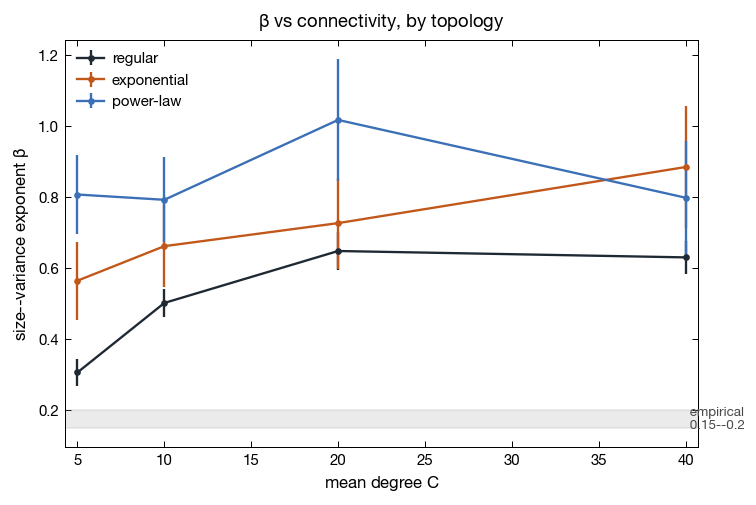

In [4]:
fig, ax = plt.subplots(figsize=(6.8, 4.4))
for name in topologies:
    Cs = np.array(C_VALUES, dtype=float)
    bet = np.array([data[name][C]["beta"] for C in C_VALUES])
    err = np.array([data[name][C]["beta_err"] for C in C_VALUES])
    ax.errorbar(Cs, bet, yerr=err, fmt="o-", color=colors[name], capsize=2.5, label=name)
ax.axhspan(0.15, 0.20, color="#7a7d83", alpha=0.15)
ax.text(C_VALUES[-1], 0.175, " empirical\n 0.15--0.2", va="center", fontsize=8, color="#4a4a4a")
ax.set_xlabel(r"mean degree $C$")
ax.set_ylabel(r"size--variance exponent $\beta$")
ax.set_title(r"$\beta$ vs connectivity, by topology")
ax.legend()
plt.show()

## Surviving fraction

Confirmation that the dynamics sit in a regime with negligible extinction: the fraction of firms with
$\bar S_i > 10^{-2}$ (1% of the mean size) stays near $1$ across topologies and $C$, so the $\beta$ fit
uses essentially the whole population rather than a truncated survivor set.

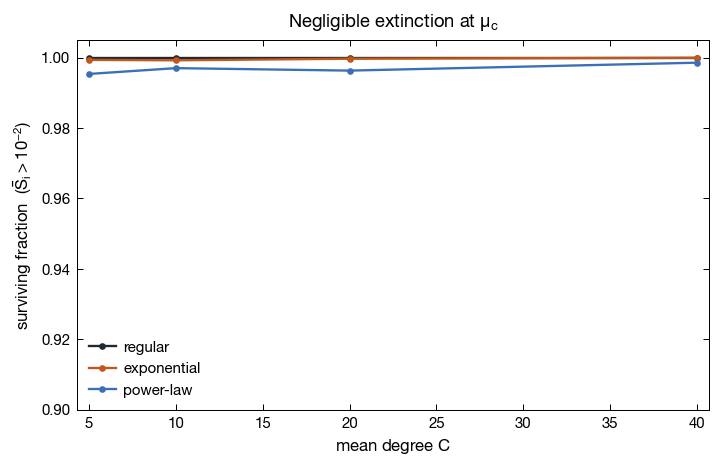

regular surviving: {5: 1.0, 10: 1.0, 20: 1.0, 40: 1.0}
exponential surviving: {5: 0.9994, 10: 0.9992, 20: 0.9997, 40: 1.0}
power-law surviving: {5: 0.9954, 10: 0.997, 20: 0.9963, 40: 0.9986}


In [5]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
for name in topologies:
    Cs = np.array(C_VALUES, dtype=float)
    surv = np.array([data[name][C]["surv"] for C in C_VALUES])
    ax.plot(Cs, surv, "o-", color=colors[name], label=name)
ax.set_xlabel(r"mean degree $C$")
ax.set_ylabel(r"surviving fraction  ($\bar S_i > 10^{-2}$)")
ax.set_ylim(0.9, 1.005)
ax.set_title(r"Negligible extinction at $\mu_c$")
ax.legend()
plt.show()
for name in topologies:
    print(name, "surviving:", {C: round(data[name][C]["surv"], 4) for C in C_VALUES})

## Size--variance fits (largest $C$)

The pooled $(\bar S_i,\sigma_i)$ and fitted slopes at the highest connectivity, $C = $ max, to show the
quality of the power-law fit underlying the exponents above.

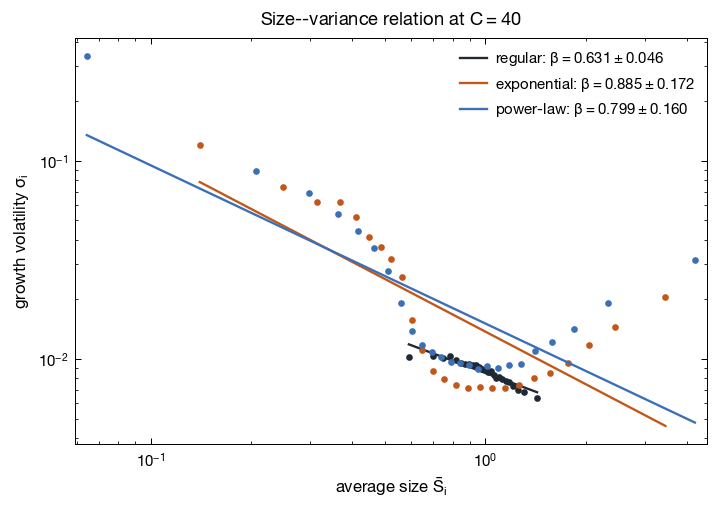

In [6]:
C_show = C_VALUES[-1]
fig, ax = plt.subplots(figsize=(6.8, 4.4))
for name in topologies:
    d = data[name][C_show]
    ax.loglog(d["bs"], d["bv"], "o", ms=4, color=colors[name])
    xfit = np.logspace(np.log10(d["bs"].min()), np.log10(d["bs"].max()), 100)
    ax.loglog(xfit, 10 ** d["intercept"] * xfit ** (-d["beta"]), "-", color=colors[name],
              label=rf"{name}: $\beta={d['beta']:.3f}\pm{d['beta_err']:.3f}$")
ax.set_xlabel(r"average size $\bar{S}_i$")
ax.set_ylabel(r"growth volatility $\sigma_i$")
ax.set_title(rf"Size--variance relation at $C={C_show}$")
ax.legend()
plt.show()

## Growth-rate distributions (largest $C$)

Pooled growth rates per topology at the highest connectivity, standardized by their own scale so the
**shapes** can be compared against the tent-shaped (Laplace-like) empirical benchmark.

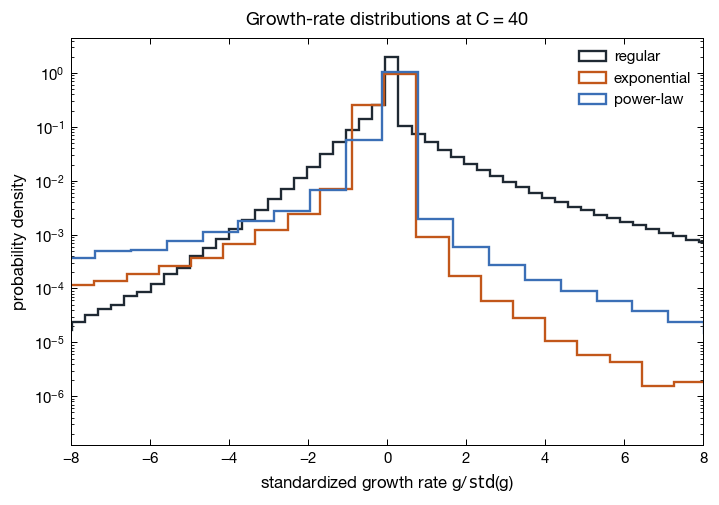

In [7]:
fig, ax = plt.subplots(figsize=(6.8, 4.4))
for name in topologies:
    g = data[name][C_show]["g"]
    g = g / g.std()
    ax.hist(g, bins=160, density=True, histtype="step", lw=1.4, color=colors[name], label=name)
ax.set_yscale("log")
ax.set_xlim(-8, 8)
ax.set_xlabel(r"standardized growth rate $g/\,\mathrm{std}(g)$")
ax.set_ylabel(r"probability density")
ax.set_title(rf"Growth-rate distributions at $C={C_show}$")
ax.legend()
plt.show()

## Summary

- **$\mu_c$** depends on topology (degree heterogeneity lowers it) and is essentially independent of $C$
  for fixed degree-distribution shape, since $\mu_c$ is governed by $\langle g^2\rangle$ with $g=k/C$.
- **Extinctions are negligible** at $\mu_c$ with $\sigma=0.2$: the surviving fraction stays near $1$, so
  $\beta$ is fit on the whole population.
- **$\beta$ vs $C$** is the headline figure: each topology's curve shows how the size--variance exponent
  responds to connectivity, with the empirical $0.15$--$0.2$ band shaded for reference.
